In [49]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np

In [50]:
df=pd.read_csv("clean_data",encoding="latin1")

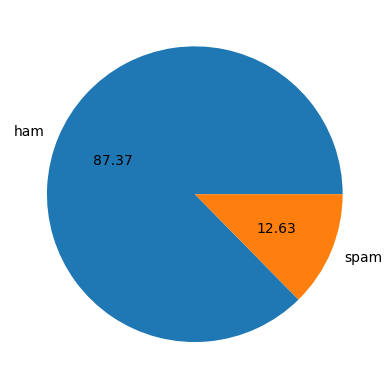

In [51]:
plt.pie(df['target'].value_counts(),labels=["ham","spam"],autopct="%0.2f")
plt.show()

In [52]:
import nltk

In [53]:
nltk.download('punkt')
nltk.download('punkt_tab')  # optional but safe
#df['words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [54]:
# ak column banne gy jo batye ga kitne character hai ak sms me
df['num_char']=df['text'].apply(len)
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [55]:
# ham worlds ko count kre gy ab NLTK ke help se
df['words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [56]:
# ab ham wb sentence ko counnt kre gy 
df['text']

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5164    This is the 2nd time we have tried 2 contact u...
5165               Will Ã_ b going to esplanade fr home?
5166    Pity, * was in mood for that. So...any other s...
5167    The guy did some bitching but I acted like i'd...
5168                           Rofl. Its true to its name
Name: text, Length: 5169, dtype: object

In [57]:
# save kre gy isko
df['num_sent']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [58]:
df.head()  # yaha data me sab clear ho gya hai ab

,target,text,num_char,words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [59]:
# ab chek kre kaise kon kitna hai
df[['num_char','words','num_sent']].describe()

,num_char,words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,79.186883,18.456761,1.966531
std,58.380576,13.325633,1.449833
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [66]:
# ye ham ke liye hai
[df['target'] == 0][['num_char','words','num_sent']].describe()

<>:2: SyntaxWarning: list indices must be integers or slices, not list; perhaps you missed a comma?
C:\Users\hp\AppData\Local\Temp\ipykernel_3540\791457395.py:2: SyntaxWarning: list indices must be integers or slices, not list; perhaps you missed a comma?
  [df['target'] == 0][['num_char','words','num_sent']].describe()
C:\Users\hp\AppData\Local\Temp\ipykernel_3540\791457395.py:2: SyntaxWarning: list indices must be integers or slices, not list; perhaps you missed a comma?
  [df['target'] == 0][['num_char','words','num_sent']].describe()


TypeError: list indices must be integers or slices, not list

In [67]:
 # ye spam ke analysis hai  --- isse kya analysis kr rhe ho dono me kya difference hota hai jaise unki lenth
df[df['target'] == 1][['num_char','words','num_sent']].describe()

,num_char,words,num_sent
count,653.000000,653.000000,653.000000
mean,138.738132,27.675345,2.978560
std,30.418104,7.011513,1.493185
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,158.000000,32.000000,4.000000
max,226.000000,46.000000,9.000000


In [68]:
import seaborn as sb

<Figure size 1300x600 with 0 Axes>

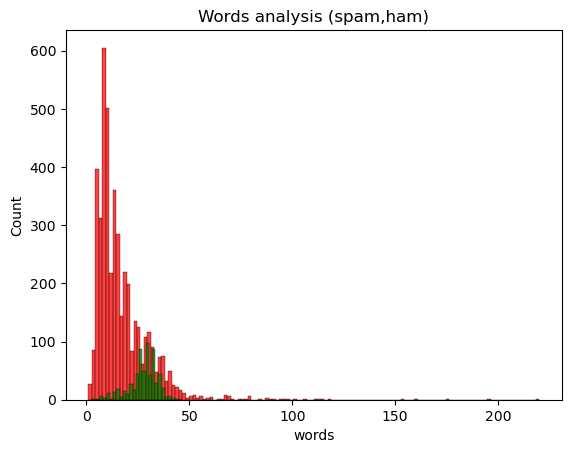

<Figure size 1300x600 with 0 Axes>

In [69]:
# ab ham graph ki help se samjhe gy kaise dono me difference hai
# histogram ban rha hai
plt.title('Words analysis (spam,ham)')
sb.histplot(df[df['target'] == 0]['words'],color='red')
sb.histplot(df[df['target'] == 1]['words'],color='green')
# ye hota hai usko acche se show krne ke liye

plt.figure(figsize=(13,6))

<Figure size 1300x600 with 0 Axes>

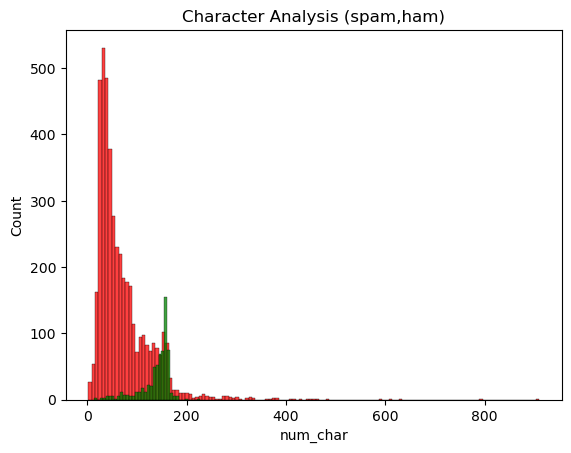

<Figure size 1300x600 with 0 Axes>

In [70]:
# baki sab ke liye analysis kre gy

sb.histplot(df[df['target'] == 0]['num_char'],color='red')
sb.histplot(df[df['target'] == 1]['num_char'],color='green')
plt.title('Character Analysis (spam,ham)')

# ye hota hai usko acche se show krne ke liye

plt.figure(figsize=(13,6))

<Figure size 1300x500 with 0 Axes>

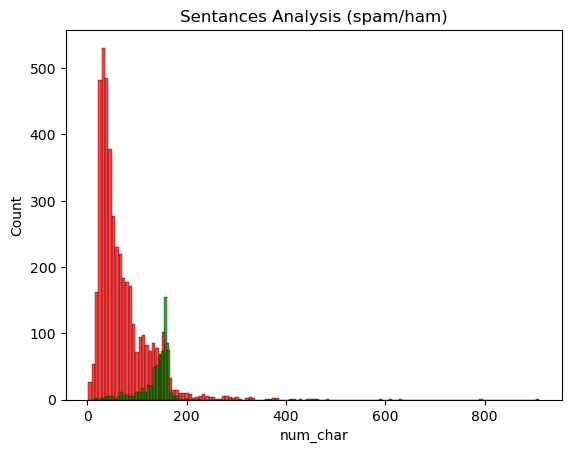

<Figure size 1300x500 with 0 Axes>

In [71]:
# ab ham sentance ka analysis kre gy
sb.histplot(df[df['target'] == 0]['num_char'],color='red')
sb.histplot(df[df['target'] == 1]['num_char'],color='green')
# title ke liye hai
plt.title('Sentances Analysis (spam/ham)')

#
plt.figure(figsize=(13,5))

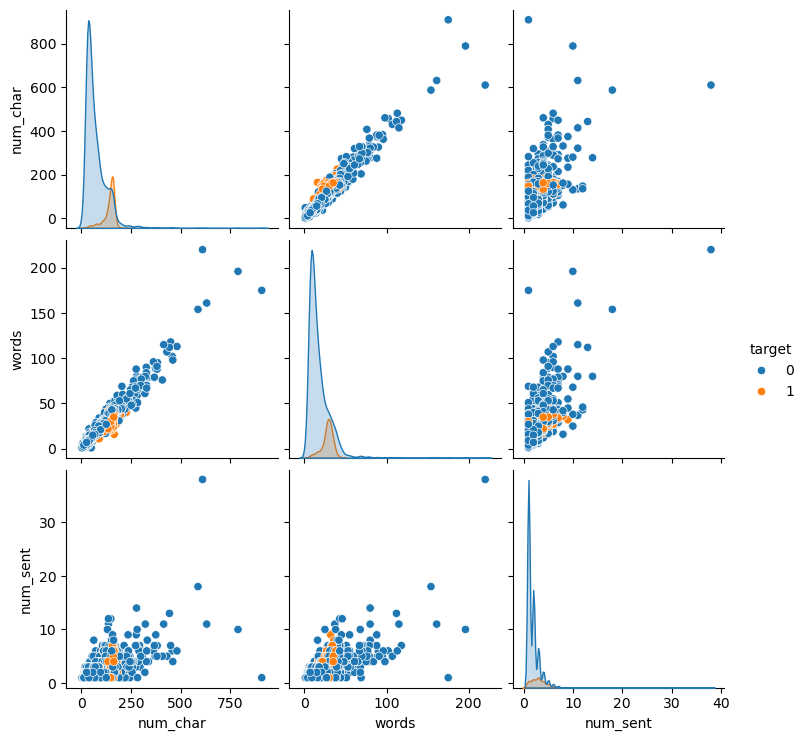

In [72]:
# Ab ham co-relation find kre gy 
sb.pairplot(df,hue='target')

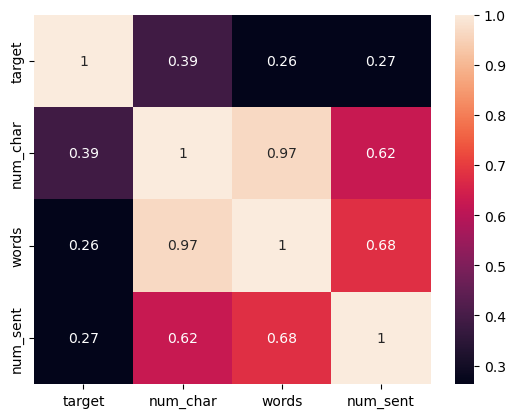

In [76]:
#import matplotlib.pyplot as plt
import seaborn as sb
import matplotlib.pyplot as plt

sb.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)  #df.corr= numerical dada represent krta hai apne pass string hai to ye use kregy
plt.show()